In [1]:
import os

import torch 
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
import torchvision.transforms as T

from numpy.typing import NDArray
import numpy as np

import cv2

import matplotlib.pyplot as plt

import glob

import random

import copy

from PIL import Image

In [2]:
def smart_pad_and_resize_ecg(image, target_size=(224, 224)):
    """
    Smarter padding that detects background color automatically
    Generated from Claude
    """
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    # Auto-detect background color (assume corners are background)
    corners = [
        image[0, 0], image[0, -1], 
        image[-1, 0], image[-1, -1]
    ]
    
    # Use most common corner color as background
    if len(image.shape) == 3:
        bg_color = np.median(corners, axis=0).astype(image.dtype)
    else:
        bg_color = np.median(corners).astype(image.dtype)
    
    h, w = image.shape[:2]
    max_dim = max(h, w)
    
    # Create padded canvas
    if len(image.shape) == 3:
        padded = np.full((max_dim, max_dim, image.shape[2]), bg_color, dtype=image.dtype)
    else:
        padded = np.full((max_dim, max_dim), bg_color, dtype=image.dtype)
    
    # Center the image
    y_offset = (max_dim - h) // 2
    x_offset = (max_dim - w) // 2
    padded[y_offset:y_offset + h, x_offset:x_offset + w] = image

    # sharpen image
    kernel = np.array([[-0.5, -0.5, -0.5],
                       [-0.5,  5.0, -0.5],
                       [-0.5, -0.5, -0.5]])
    
    sharpened = cv2.filter2D(padded, -1, kernel)
    # Blend original and sharpened (subtle effect)
    enhanced = cv2.addWeighted(padded, 0.7, sharpened, 0.3, 0)
    
    # Resize with appropriate interpolation
    resized = cv2.resize(padded, target_size, interpolation=cv2.INTER_AREA)
    
    return resized 

## Manual

In [3]:
def get_model(model_path, device=None):
    checkpoints = torch.load(model_path, map_location=device, weights_only=True)
    model = deeplabv3_mobilenet_v3_large(num_classes=2, aux_loss=True).to(device)
    model.load_state_dict(checkpoints, strict=False)
    return model 

In [4]:
def image_preprocess_transforms(mean=(0.4611, 0.4359, 0.3905), std=(0.2193, 0.2150, 0.2109)):
    common_transforms = T.Compose([T.ToTensor(), T.Normalize(mean, std),])
    return common_transforms

In [5]:
# Detect device 

device = torch.device(
            "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built() \
            else ("cuda" if torch.cuda.is_available() 
            else "cpu")
      )
#device = torch.device("cpu")

In [6]:
random.seed(42)

In [7]:
image_dir = os.path.join(os.path.abspath("../"), "data", "train")
images = glob.glob(os.path.join(image_dir, "train_*.png"))
image_path = random.choice(images)

img: NDArray[np.uint8] = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
og_image_size = img.shape

In [8]:
resized_img = cv2.resize(img, (384, 384), interpolation=cv2.INTER_NEAREST)
preproc_transforms = image_preprocess_transforms()
img_tens = preproc_transforms(resized_img)
img_tens = torch.unsqueeze(img_tens, dim=0).to(device)

In [9]:
model_path = os.path.join(os.path.abspath("../"), "model", "object_detection", "model_mbv3_iou_mix_2C049.pth")
model = get_model(model_path, device).to(device)
model.eval()

with torch.inference_mode(): 
    out = model(img_tens)["out"]
    
out = torch.argmax(out, dim=1, keepdims=True).permute(0, 2, 3, 1)[0].cpu().numpy().squeeze().astype(np.int32)

In [10]:
mask = out.astype(np.uint8)
resize_out = cv2.resize(mask, (og_image_size[1], og_image_size[0]), interpolation=cv2.INTER_NEAREST)

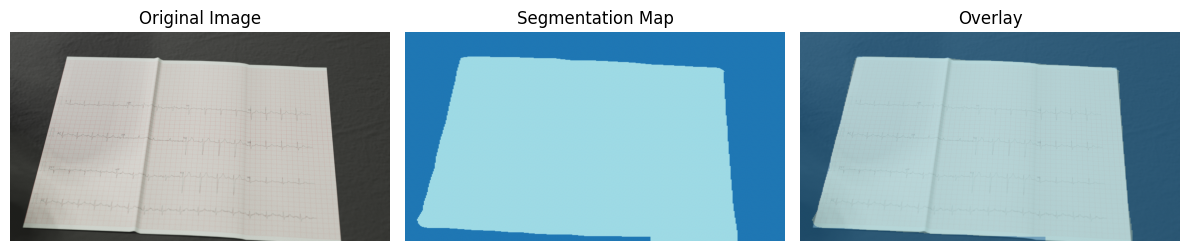

In [11]:
# Plot the segmentation
plt.figure(figsize=(12, 4))

# Original image (if you have it)
plt.subplot(1, 3, 1)
if 'img' in locals():
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

# Segmentation map
plt.subplot(1, 3, 2)
plt.imshow(resize_out, cmap='tab20')  # Good colormap for segmentation
plt.title('Segmentation Map')
plt.axis('off')

# Overlay (if you have original image)
plt.subplot(1, 3, 3)
if 'img' in locals():
    plt.imshow(img)
    plt.imshow(resize_out, alpha=0.5, cmap='tab20')
    plt.title('Overlay')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Full Pipeline

In [12]:
def generate_output(image: np.array, corners: np.ndarray, scale: tuple = None):
    """Generates a perspective-transformed output image."""
    corners = order_points(corners)  # Ensure correct point order

    if scale is not None:
        corners *= np.array(scale, dtype=np.float32)  # Vectorized multiplication

    destination_corners = find_dest(corners)  # Get transformation target points
    M = cv2.getPerspectiveTransform(corners, destination_corners)  # Perspective matrix

    max_width, max_height = map(int, destination_corners[2])  # Extract output size
    out = cv2.warpPerspective(image, M, (max_width, max_height), flags=cv2.INTER_LANCZOS4)

    return np.clip(out, 0, 255).astype(np.uint8)  # Ensure valid pixel values

def order_points(pts: np.ndarray) -> np.ndarray:
    """Rearranges points to: top-left, top-right, bottom-right, bottom-left."""
    pts = np.asarray(pts, dtype=np.float32)  # Ensure NumPy array
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)

    rect = np.zeros((4, 2), dtype=np.float32)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left

    return rect  # Already a NumPy array, no conversion needed

def find_dest(pts: np.ndarray) -> np.ndarray:
    """Computes destination points based on max width and height."""
    (tl, tr, br, bl) = pts  # Unpack ordered points

    # Compute max width and height
    width = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))
    height = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))

    return np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype=np.float32)

def image_preprocess_transforms(mean=(0.4611, 0.4359, 0.3905), std=(0.2193, 0.2150, 0.2109)):
    common_transforms = T.Compose([T.ToTensor(), T.Normalize(mean, std),])
    return common_transforms

def get_model(model_path, device=None):
    checkpoints = torch.load(model_path, map_location=device, weights_only=True)
    model = deeplabv3_mobilenet_v3_large(num_classes=2, aux_loss=True).to(device)
    model.load_state_dict(checkpoints, strict=False)
    return model 

def deep_learning_scan(
        og_image: np.array = None, 
        trained_model=None, 
        image_size=384, 
        BUFFER=10, 
        preprocess_transforms=image_preprocess_transforms(), 
        device='cpu'):

    half = image_size // 2
    imH, imW, C = og_image.shape
    
    image_model = smart_pad_and_resize_ecg(og_image, target_size=(image_size, image_size))
    #image_model = cv2.resize(og_image, (image_size, image_size), interpolation=cv2.INTER_LANCZOS4)
    scale_x = imW / image_size
    scale_y = imH / image_size
    
    
    image_model = preprocess_transforms(image_model)
    image_model = torch.unsqueeze(image_model, dim=0)
    
    image_model = image_model.to(device)

    # # Device on CPU
    model_cpu = trained_model.to(device)
    model_cpu.eval()
    
    # Rest of your preprocessing remains the same, but use model_cpu
    with torch.no_grad():
        out = model_cpu(image_model)["out"]

    out = torch.argmax(out, dim=1, keepdims=True).permute(0, 2, 3, 1)[0].cpu().numpy().squeeze().astype(np.int32)
    out_intermediate = copy.deepcopy(out)
    r_H, r_W = out.shape

    out = np.pad(out * 255, pad_width=((half, half), (half, half)), mode='constant')

    # Edge Detection.
    canny = cv2.Canny(out.astype(np.uint8), 225, 255)
    canny = cv2.dilate(canny, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    contours, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if not contours: 
        return None

    page = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(page, True)
    corners = cv2.approxPolyDP(page, epsilon, True)
    corners = np.concatenate(corners).astype(np.float32)

    corners[:, 0] -= half
    corners[:, 1] -= half
    corners[:, 0] *= scale_x
    corners[:, 1] *= scale_y
    
    if not (np.all(corners.min(axis=0) >= (0, 0)) and np.all(corners.max(axis=0) <= (imW, imH))):

        left_pad, top_pad, right_pad, bottom_pad = 0, 0, 0, 0

        box_corners = cv2.boxPoints(cv2.minAreaRect(corners.reshape((-1, 1, 2)))).astype(np.int32)

        box_x_min, box_y_min = np.min(box_corners, axis=0)
        box_x_max, box_y_max = np.max(box_corners, axis=0)

        # Find corner point which doesn't satify the image constraint
        # and record the amount of shift required to make the box
        # corner satisfy the constraint

        left_pad, right_pad = max(-box_x_min, 0) + BUFFER, max(box_x_max - imW, 0) + BUFFER
        top_pad, bottom_pad = max(-box_y_min, 0) + BUFFER, max(box_y_max - imH, 0) + BUFFER

        # # new image with additional zeros pixels
        # # adjust original image within the new 'image_extended'

        image_extended = np.pad(og_image, ((top_pad, bottom_pad), (left_pad, right_pad), (0, 0)), mode='constant')

        # shifting 'box_corners' the required amount
        box_corners[:, 0] += left_pad
        box_corners[:, 1] += top_pad

        corners = box_corners
        og_image = image_extended

    corners = sorted(corners.tolist())
    return generate_output(og_image, corners), out_intermediate, contours

In [13]:
output_image, intermediate, contours = deep_learning_scan(
                                        og_image=img, 
                                        trained_model=model, 
                                        device=device,
                                        BUFFER = 0,
                                        image_size = 512
                                        )

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

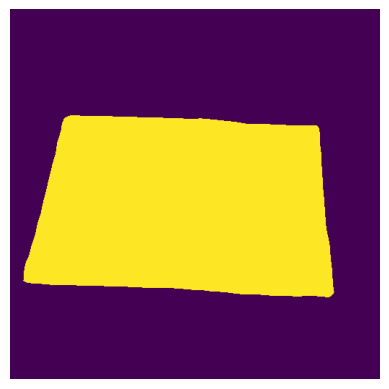

In [14]:
fig, ax = plt.subplots()
ax.imshow(intermediate)
ax.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

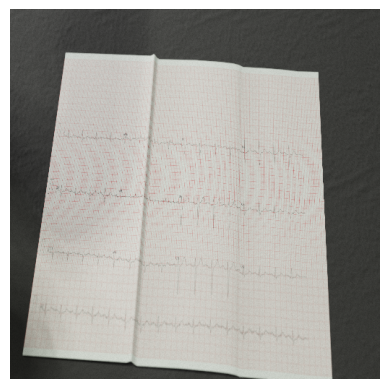

In [15]:
fig, ax = plt.subplots()
ax.imshow(cv2.resize(img, (512, 512), interpolation=cv2.INTER_LANCZOS4))
ax.axis("off")

(np.float64(-0.5), np.float64(2925.5), np.float64(922.5), np.float64(-0.5))

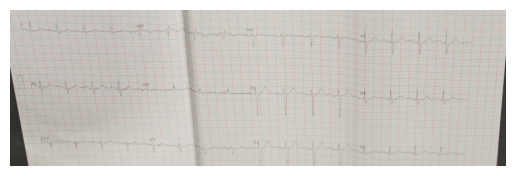

In [16]:
fig, ax = plt.subplots()
ax.imshow(output_image)
ax.axis("off")

In [17]:
contours_elem = contours[0]

In [18]:
contours_elem_16 = contours_elem.astype(np.int16)

In [19]:
contours_elem

array([[[340, 400]],

       [[339, 401]],

       [[338, 401]],

       ...,

       [[343, 400]],

       [[342, 400]],

       [[341, 400]]], shape=(1250, 1, 2), dtype=int32)

In [20]:
np.all(contours_elem_16 == contours_elem)

np.True_